# 1. Setup Ambiente e Librerie
Installiamo le librerie necessarie: `torchattacks` per generare rapidamente gli adversarial examples e `facenet-pytorch` per InceptionResnetV1.

In [1]:
!pip install torchattacks facenet-pytorch

# 2. Import e Montaggio Google Drive
Assicurati di accettare i permessi per connettere Drive.

In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from google.colab import drive
from facenet_pytorch import InceptionResnetV1
import torchattacks

drive.mount('/content/drive')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nDevice in uso: {device}")
if device.type != 'cuda':
    print("ATTENZIONE: Attiva la GPU T4 in Runtime -> Cambia tipo di runtime per velocizzare l'addestramento.")

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Mounted at /content/drive

Device in uso: cuda


# 3. Caricamento Dataset (Le 100 Identità)
Inserisci il path corretto verso la tua cartella in Drive. Il codice dividerà automaticamente in Train e Test Set.

In [16]:
import os
import zipfile
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import cv2
import numpy as np

# 1. Percorsi e Estrazione
ZIP_PATH = '/content/drive/MyDrive/100_identities_cropped/NN1.zip'
EXTRACT_PATH = '/content/local_dataset/'

if not os.path.exists(EXTRACT_PATH):
    os.makedirs(EXTRACT_PATH)
    print(f"Estrazione di {ZIP_PATH} in corso...")
    try:
        with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
            zip_ref.extractall(EXTRACT_PATH)
        print("Estrazione completata!")
    except Exception as e:
        print(f"ERRORE di estrazione: {e}")

DATA_DIR = EXTRACT_PATH
subdirs = [os.path.join(DATA_DIR, d) for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]
if len(subdirs) == 1:
    DATA_DIR = subdirs[0]

# --- 2. CREAZIONE DEL CUSTOM DATASET FLOAT-TIFF ---
class FloatTIFFDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []

        self.classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

        print("Scansione file TIFF (Float32) in corso...")
        corrupted = 0

        for cls_name in self.classes:
            cls_dir = os.path.join(root_dir, cls_name)
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith(('.tiff', '.tif')):
                    img_path = os.path.join(cls_dir, fname)

                    # Usiamo IMREAD_UNCHANGED per leggere i float32 senza crashare
                    if cv2.imread(img_path, cv2.IMREAD_UNCHANGED) is not None:
                        self.image_paths.append(img_path)
                        self.labels.append(self.class_to_idx[cls_name])
                    else:
                        corrupted += 1

        print(f"Scansione terminata. Trovati {corrupted} file realmente corrotti/vuoti.")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        # 1. Legge il float32
        image = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)

        # 2. Converte da BGR a RGB se ha 3 canali
        if len(image.shape) == 3 and image.shape[2] == 3:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # 3. Conversione da Float32 a uint8 [0-255]
        if image.dtype == np.float32 or image.dtype == np.float64:
            # Se i valori sono tra -1.0 e 1.0 (classico output di MTCNN) li portiamo a 0.0 - 1.0
            if image.min() < 0:
                image = (image + 1.0) / 2.0

            # Se sono rimasti decimali (max <= 1.0), moltiplichiamo per 255
            if image.max() <= 1.0:
                image = image * 255.0

            # Tagliamo gli eccessi e convertiamo in interi
            image = np.clip(image, 0, 255).astype(np.uint8)

        # 4. Applica trasformazioni PyTorch (ToTensor scala di nuovo i uint8 [0-255] in float [0-1])
        if self.transform:
            image = self.transform(image)

        return image, label

# --- 3. CARICAMENTO DATI ---
transform = transforms.Compose([
    transforms.ToPILImage(), # Necessario come ponte prima del Resize
    transforms.Resize((160, 160)),
    transforms.ToTensor()
])

try:
    full_dataset = FloatTIFFDataset(root_dir=DATA_DIR, transform=transform)
    print(f"\nSUCCESSO: Trovate {len(full_dataset)} immagini TIFF valide in {len(full_dataset.classes)} identità.")

    torch.manual_seed(42)
    train_size = int(0.8 * len(full_dataset))
    test_size = len(full_dataset) - train_size
    train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

except Exception as e:
    print("ERRORE nel Dataloader:")
    print(e)

Scansione file TIFF (Float32) in corso...
Scansione terminata. Trovati 0 file realmente corrotti/vuoti.

SUCCESSO: Trovate 915 immagini TIFF valide in 100 identità.


# 4. Architettura Autoencoder Convoluzionale
Una rete leggera creata appositamente per addestrarsi in 2 minuti su Colab.

In [17]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1), # -> 32x80x80
            nn.ReLU(True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # -> 64x40x40
            nn.ReLU(True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), # -> 128x20x20
            nn.ReLU(True)
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1), # -> 64x40x40
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1), # -> 32x80x80
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 3, kernel_size=3, stride=2, padding=1, output_padding=1), # -> 3x160x160
            nn.Sigmoid() # Scala l'output nel range [0, 1] per calcolare MSE corretto
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

autoencoder = DenoisingAutoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(autoencoder.parameters(), lr=1e-3)

# 5. Training Loop e Salvataggio Modello
Addestriamo solo sulle immagini pulite per imparare la loro distribuzione normale.

In [21]:
EPOCHS = 100
best_loss = float('inf')
SAVE_PATH = '/content/drive/MyDrive/best_autoencoder_defense.pth'

print("Inizio Addestramento Autoencoder...")
for epoch in range(EPOCHS):
    autoencoder.train()
    train_loss = 0.0

    for images, _ in train_loader:
        images = images.to(device)
        optimizer.zero_grad()
        outputs = autoencoder(images)
        loss = criterion(outputs, images) # Impara a ricostruire l'immagine originale
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    # Validation
    autoencoder.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            outputs = autoencoder(images)
            loss = criterion(outputs, images)
            val_loss += loss.item()
    val_loss /= len(test_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.5f} | Val Loss: {val_loss:.5f}")

    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(autoencoder.state_dict(), SAVE_PATH)
        print("  --> Nuovo miglior modello salvato su Drive!")

print("Addestramento completato.")

Inizio Addestramento Autoencoder...
Epoch 1/100 | Train Loss: 0.00206 | Val Loss: 0.00192
  --> Nuovo miglior modello salvato su Drive!
Epoch 2/100 | Train Loss: 0.00186 | Val Loss: 0.00184
  --> Nuovo miglior modello salvato su Drive!
Epoch 3/100 | Train Loss: 0.00194 | Val Loss: 0.00179
  --> Nuovo miglior modello salvato su Drive!
Epoch 4/100 | Train Loss: 0.00170 | Val Loss: 0.00166
  --> Nuovo miglior modello salvato su Drive!
Epoch 5/100 | Train Loss: 0.00166 | Val Loss: 0.00196
Epoch 6/100 | Train Loss: 0.00162 | Val Loss: 0.00152
  --> Nuovo miglior modello salvato su Drive!
Epoch 7/100 | Train Loss: 0.00148 | Val Loss: 0.00153
Epoch 8/100 | Train Loss: 0.00187 | Val Loss: 0.00144
  --> Nuovo miglior modello salvato su Drive!
Epoch 9/100 | Train Loss: 0.00139 | Val Loss: 0.00134
  --> Nuovo miglior modello salvato su Drive!
Epoch 10/100 | Train Loss: 0.00129 | Val Loss: 0.00132
  --> Nuovo miglior modello salvato su Drive!
Epoch 11/100 | Train Loss: 0.00123 | Val Loss: 0.00118


# 6. Generazione Attacchi e Calcolo Errori
Usiamo la rete bersaglio (InceptionResnetV1) per generare PGD attacks (eps=0.1 pari al 10% del range), e passiamo tutto al nostro autoencoder.

In [22]:
# 1. Carica il classificatore Target
resnet = InceptionResnetV1(pretrained='vggface2').eval().to(device)
resnet.classify = True

# 2. Carica il nostro autoencoder migliore
autoencoder.load_state_dict(torch.load(SAVE_PATH))
autoencoder.eval()

# 3. Setup Attacco PGD (eps=10% del range [0,1] -> 0.1)
attack = torchattacks.PGD(resnet, eps=0.1, alpha=0.01, steps=10)

mse_clean_list = []
mse_adv_list = []
criterion_mse = nn.MSELoss(reduction='none')

print("Generazione attacchi PGD e scansione anomalie in corso...")
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)

    # Genera gli esempi avversari "al volo"
    adv_images = attack(images, labels)

    with torch.no_grad():
        # Misura l'errore di ricostruzione (MSE) sulle immagini Clean
        rec_clean = autoencoder(images)
        mse_c = criterion_mse(rec_clean, images).view(images.size(0), -1).mean(dim=1)
        mse_clean_list.extend(mse_c.cpu().numpy())

        # Misura l'errore di ricostruzione (MSE) sugli Adversarial
        rec_adv = autoencoder(adv_images)
        mse_a = criterion_mse(rec_adv, adv_images).view(adv_images.size(0), -1).mean(dim=1)
        mse_adv_list.extend(mse_a.cpu().numpy())

mse_clean_list = np.array(mse_clean_list)
mse_adv_list = np.array(mse_adv_list)

print(f"MSE Medio su Clean Dataset: {mse_clean_list.mean():.5f}")
print(f"MSE Medio su Adversarial Dataset: {mse_adv_list.mean():.5f}")

Generazione attacchi PGD e scansione anomalie in corso...
MSE Medio su Clean Dataset: 0.00044
MSE Medio su Adversarial Dataset: 0.00350


# 7. Valutazione e Anomaly Detection
Stampiamo i grafici per il documento e calcoliamo l'accuratezza del nostro Detector.

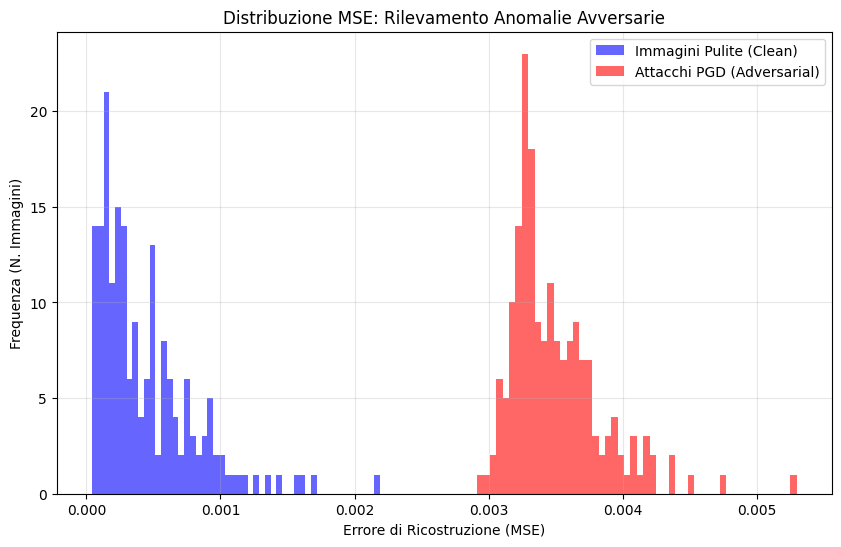


>>> SOGLIA DI ANOMALIA (Threshold): 0.00197 <<<

Risultati Detector (Difesa):
- Falsi Positivi (Clean droppati): 1/183 (0.55%)
- Veri Positivi (Attacchi fermati): 183/183 (100.00%)


In [23]:
# Istogramma Distribuzione Errori
plt.figure(figsize=(10,6))
plt.hist(mse_clean_list, bins=50, alpha=0.6, label='Immagini Pulite (Clean)', color='blue')
plt.hist(mse_adv_list, bins=50, alpha=0.6, label='Attacchi PGD (Adversarial)', color='red')
plt.legend()
plt.xlabel('Errore di Ricostruzione (MSE)')
plt.ylabel('Frequenza (N. Immagini)')
plt.title('Distribuzione MSE: Rilevamento Anomalie Avversarie')
plt.grid(alpha=0.3)
plt.show()

# Calcolo Soglia Dinamica (A metà tra le medie di Clean e Adv)
threshold = (mse_clean_list.mean() + mse_adv_list.mean()) / 2
print(f"\n>>> SOGLIA DI ANOMALIA (Threshold): {threshold:.5f} <<<")

# Falsi Positivi (Clean bloccati erroneamente come attacchi)
fp = np.sum(mse_clean_list > threshold)
# Veri Positivi (Attacchi rilevati e bloccati con successo)
tp = np.sum(mse_adv_list > threshold)

print(f"\nRisultati Detector (Difesa):")
print(f"- Falsi Positivi (Clean droppati): {fp}/{len(mse_clean_list)} ({(fp/len(mse_clean_list))*100:.2f}%)")
print(f"- Veri Positivi (Attacchi fermati): {tp}/{len(mse_adv_list)} ({(tp/len(mse_adv_list))*100:.2f}%)")